In [1]:
import sys
print(sys.executable)

/Users/bala/python-envs/AI_Agents/bin/python


In [2]:
import fitz 

In [68]:
eu_ai_act = "./eu_ai_act.pdf"
doc = fitz.open(eu_ai_act)

In [69]:
from pprint import pprint
print(doc[0].rect.width, doc[0].rect.br)
blocks = doc[0].get_text("dict")["blocks"]
pprint(blocks[0])
# A block is a large rectangel region of content
# Inside each block we have lines (lines of text)
# Inside each lines we have spans (each span is the smallest unit of text we have) --> span have [bbox, text, font, size, etc]


595.0 Point(595.0, 842.0)
{'bbox': (105.80230712890625,
          98.00457000732422,
          489.4858093261719,
          109.43498229980469),
 'flags': 0,
 'lines': [{'bbox': (105.80230712890625,
                     98.00457000732422,
                     489.4858093261719,
                     109.43498229980469),
            'dir': (1.0, 0.0),
            'spans': [{'alpha': 255,
                       'ascender': 0.949999988079071,
                       'bbox': (105.80230712890625,
                                98.00457000732422,
                                166.0218963623047,
                                109.43498229980469),
                       'bidi': 0,
                       'char_flags': 24,
                       'color': 2236193,
                       'descender': -0.25,
                       'flags': 20,
                       'font': 'EUAlbertina-Bold',
                       'origin': (105.80230712890625, 107.05364990234375),
                       'size'

In [70]:

import re


doc = fitz.open(eu_ai_act)

FLAG_BOLD   = 16
FLAG_ITALIC = 2

chunks = []
ctx = {"chapter_num":"", "chapter_title":"", "section_num":"", "section_title":"",
      "article":"", "article_title":""}
current = None
current_page = None

# This flush will append the current content to the chunk 
# whenever called
def flush():
    if current and current['text'].strip():
        chunks.append({**current, **ctx.copy()})


for page_num, page in enumerate(doc):
    pw = page.rect.width
    real_page = page_num+1

    for block in page.get_text('dict')['blocks']:
        # If block type == 0 --> text , 1 --> image, 2 --> drawing, etc
        if block['type'] !=0:
            continue
        for line in block['lines']:
            #Aggregate all spans in a line into one logical span
            line_text = ""
            line_bold = False
            line_ital = False
            line_sizes = []
            x0, x1 = line["bbox"][0], line["bbox"][2]
            centered = abs((x0 +x1)/2 - pw/2) <30
            for s in line['spans']:
                # Inside each lines we have spans 
                #(each span is the smallest unit of text we have) 
                #--> span have [bbox, text, font, size, etc]
                line_text +=s['text']
                #Makes the line bold if any one span is bold, and bold means size bigger than 16 (FLAG_BOLD)
                line_bold = line_bold or bool(s['flags'] & FLAG_BOLD)
                line_ital = line_ital or bool(s['flags'] & FLAG_ITALIC)
                line_sizes.append(s['size'])
                
            text = line_text.strip()
            if not text:
                continue
            
            # For each line we need to check the type of line
            if centered:
                if re.match(r"^SECTION\s+\d+$", text):
                    kind = "section_num"
                if re.match(r"^Article\s+\d+$", text):
                    kind = "article_num"
                if line_bold and line_ital:
                    kind = "section_title"
                if re.match(r"^CHAPTER\s+[IVXLC]+$", text):
                    kind = "chapter_num"
                if line_bold and text.isupper():
                    kind = "chapter_title"
                if line_bold and not line_ital and not text.isupper():
                    kind = "article_title"
            else:
                kind = "body"
            
            
            
            if kind == "chapter_num":
                # whenever we see a new chapter num, we are flushing
                # means, if untill now something was there in current
                # will be added to chunks, and current will be emptied
                # And also ctx will be updated about the new chapter title

                flush(); current = None
                ctx.update(chapter_num=text, chapter_title="",
                           section_num="", section_title="",
                           article="", article_title=""
                )
                
            elif kind == "chapter_title":
                ctx['chapter_title'] = text
                    
                    
            elif kind == "section_num":
                flush(); current = None
                ctx.update(section_num=text, section_title="",
                          article="", article_title="")
            
            elif kind == "section_title":
                ctx["section_title"] = text
            
            elif kind == "article_num":
                flush()
                # when starting a new article we are starting a new current
                # and it will get updated untill next article comes or become
                #none if next chapter, section etc comes
                current = {"page_start": real_page,
                           "page_end": real_page,
                           "text":f"\n<<Page {real_page}>>\n"}
                current_page = real_page
                ctx.update(article=text, article_title="")
                
            elif kind == "article_title" and current is not None:
                ctx["article_title"] = text
            
            else:
                if current is None:
                    current = {"page_start": real_page,
                               "text":f"\n<<Page {real_page}>>\n",
                              "page_end": real_page}
                    current_page = real_page
                
                # if page boundary crossed, we are adding the 
                # page details in the text itself
                if real_page !=current_page:
                    current["text"] += f"\n<<Page {real_page}>>\n"
                    current["page_end"] = real_page
                    current_page = real_page
                    
                # Here is the actual comtent of the current is appended
                current["text"] += text + "\n"
                                    
                            
flush()            

doc.close()


In [71]:
chunks[6]

{'page_start': 53,
 'page_end': 54,
 'text': '\n<<Page 53>>\n1.\nIrrespective of whether an AI system is placed on the market or put into service independently of the products\nreferred to in points (a) and (b), that AI system shall be considered to be high-risk where both of the following conditions\nare fulfilled:\n(a) the AI system is intended to be used as a safety component of a product, or the AI system is itself a product, covered by\nthe Union harmonisation legislation listed in Annex I;\n(b) the product whose safety component pursuant to point (a) is the AI system, or the AI system itself as a product, is\nrequired to undergo a third-party conformity assessment, with a view to the placing on the market or the putting into\nservice of that product pursuant to the Union harmonisation legislation listed in Annex I.\n2.\nIn addition to the high-risk AI systems referred to in paragraph 1, AI systems referred to in Annex III shall be\nconsidered to be high-risk.\nOJ L, 12.7.2024\nEN

In [72]:
print(len(chunks))
print(sum([bool(chunk['chapter_title']) for chunk in chunks]))
print(sum([bool(chunk['chapter_num']) for chunk in chunks]))
print(sum([bool(chunk['section_num']) for chunk in chunks]))
print(sum([bool(chunk['section_title']) for chunk in chunks]))
print(sum([bool(chunk['article']) for chunk in chunks]))
print(sum([bool(chunk['article_title']) for chunk in chunks]))

114
114
113
80
80
113
114


In [73]:
char_count = [len(chunk['text']) for chunk in chunks]
avg = sum(char_count[1:])/len(char_count[1:])
print(avg)
print(max(char_count))
print(char_count)

3023.433628318584
244933
[244933, 1126, 4839, 17515, 85, 11268, 4086, 3628, 1339, 4227, 4546, 1878, 1179, 3158, 3222, 2446, 1605, 3711, 1350, 835, 1099, 973, 3042, 2686, 2703, 3937, 7610, 2938, 1715, 1689, 1865, 4345, 107, 896, 1130, 417, 6661, 1261, 687, 104, 2784, 3943, 848, 5004, 1442, 1838, 3393, 1972, 1398, 2064, 4669, 1165, 3061, 3565, 2800, 1829, 4462, 9284, 4751, 4342, 7875, 1439, 2140, 904, 225, 2966, 4485, 2048, 3174, 909, 3641, 2337, 2229, 4118, 7170, 1805, 1927, 1762, 3760, 5583, 2718, 1994, 1966, 1067, 511, 310, 934, 44, 731, 965, 981, 1761, 2316, 1017, 100, 2332, 1531, 2468, 253, 5475, 3509, 2173, 916, 958, 883, 973, 987, 864, 2686, 875, 136, 1814, 5698, 46683]


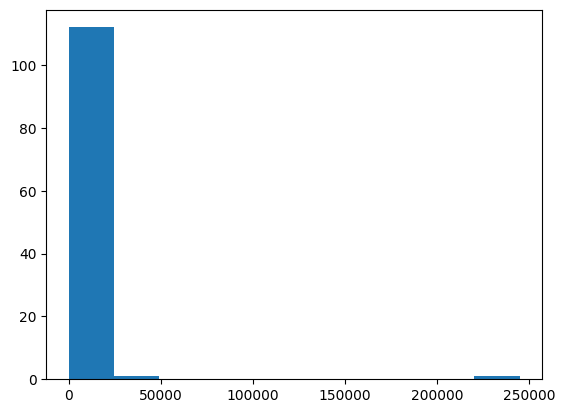

In [74]:
from collections import Counter
import numpy as np
from matplotlib import pyplot as plt
arr = np.array(char_count)
plt.hist(arr)
plt.show()


In [75]:
import json

with open('chunks.json', 'w') as f:
    json.dump(chunks, f)

In [76]:
from langchain_core.documents import Document

def to_document(chunk: dict) -> Document:
    return Document(
        page_content = chunk['text'],
        metadata = {
            'article':       chunk['article'],
            'article_title': chunk['article_title'],
            'chapter_num':   chunk['chapter_num'],
            'chapter_title': chunk['chapter_title'],
            'section_num':   chunk['section_num'],
            'section_title': chunk['section_title'],
#             'page_start':    chunk['page_start'],
#             'page_end':      chunk['page_end'],
            'source': f"{chunk['article']} — {chunk['article_title']}",#(pp. {chunk['page_start']}–{chunk['page_end']})
        }
    )

docs = [to_document(c) for c in chunks]


In [77]:
docs[4]

Document(metadata={'article': 'Article 4', 'article_title': 'technical knowledge, experience, education and training and the context the AI systems are to be used in, and considering', 'chapter_num': 'CHAPTER I', 'chapter_title': 'GENERAL PROVISIONS', 'section_num': '', 'section_title': '', 'source': 'Article 4 — technical knowledge, experience, education and training and the context the AI systems are to be used in, and considering'}, page_content='\n<<Page 51>>\nthe persons or groups of persons on whom the AI systems are to be used.\n')

In [78]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

recursive_chunker = RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=200, 
                                                   separators=["\n\n", "\n", ". ", " ", ""], add_start_index=True)

In [101]:
def extract_page_segments(doc):
    content = doc.page_content
    page_marker = re.compile(r"\n<<Page (\d+)>>\n")
    splits = page_marker.split(content)[1:]
    segments: list[tuple[int,str]] = []
    for i in range(0,len(splits)-1, 2):
        page_num = splits[i]
        text = splits[i+1]
        segments.append((page_num, text))
    return segments

def split_with_page_awareness(doc, recursive_chunker):
    
    segment = extract_page_segments(doc)
    all_sub_chunks = []
    for page_num, text in segment:
        if not text.strip():
            continue
        seg_document = Document(
            page_content=text,
            metadata={
                **doc.metadata,
                "page_num": page_num,
                "source": f"""{doc.metadata['article']} — {doc.metadata['article_title']} 
                (p. {page_num})"""
                
            }
        )
        for sub_chunk in recursive_chunker.split_documents([seg_document]):
            sub_chunk.metadata['page_num'] = page_num
            all_sub_chunks.append(sub_chunk)
    return all_sub_chunks
    

final_chunks = []

for doc in docs:
    final_chunks.extend(split_with_page_awareness(doc, recursive_chunker))


432 [1938 1367 1888 1901 1569 1898 1942 1909 1433 1982 1899 1823 1930 1942
 1899  783 1958 1973 1988 1927 1950 1908 1907 1890 1922  713 1992 1963
 1952 1972 1975 1870  382 1997 1981 1925  432 1960 1943 1463 1948 1928
 1787 1919 1963 1938  278 1964 1926 1944 1953 1972 1971  309 1958 1985
 1991  297 1995 1933 1912  421 1992 1901 1913  428 1899 1931 1660 1969
 1971 1993  716 1919 1990 1977  186 1925 1895 1929  387 1980 1999 1595
 1944 1890 1830 1965 1926 1950 1958 1906 1956  287 1982 1937 1167 1896
 1918 1950  533 2000 1900 1443 1950 1889 1993  360 1978 1984 1720 1887
 1945 1952  430 1939 1963 1933  294 2000 1937 1926  415 1997 1936 1983
  591 1908 1919 1952  260 1957 1890 1747 1958 1938 1837 1938 1915 1897
  417 1907 1925 1650 1904 1929 1878 1894 1958 1724 1961 1537  649  449
 1998 1132 1831 1967  234 1917 1993  230 1881 1893  374 1919 1877 1961
 1965  386   71 1971 1289 1944 1985 1140 1960 1482  981 1952 1240  632
 1953 1137  422  889 1940 1004 1376 1942  607 1935  250 1864 1165 1808
 1

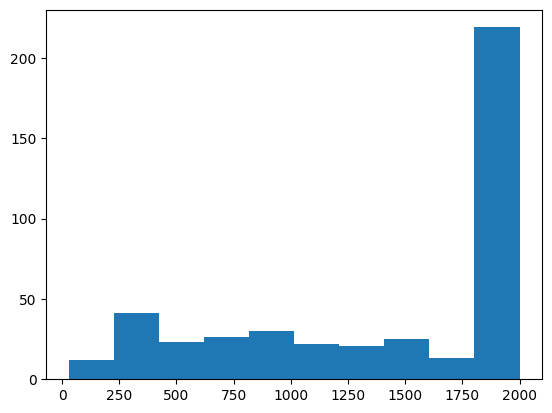

In [112]:
chunk_sizes = [len(chunk.page_content) for chunk in final_chunks]
arr = np.array(chunk_sizes)
print(arr.size, arr)
plt.hist(arr)
plt.show()

In [119]:
final_chunks[3]

Document(metadata={'article': '', 'article_title': '(Text with EEA relevance)', 'chapter_num': '', 'chapter_title': 'REGULATION (EU) 2024/1689 OF THE EUROPEAN PARLIAMENT AND OF THE COUNCIL', 'section_num': '', 'section_title': '', 'source': ' — (Text with EEA relevance) \n                (p. 2)', 'page_num': '2', 'start_index': 1734}, page_content='change mitigation and adaptation.\n(5)\nAt the same time, depending on the circumstances regarding its specific application, use, and level of technological\ndevelopment, AI may generate risks and cause harm to public interests and fundamental rights that are protected by\nUnion law. Such harm might be material or immaterial, including physical, psychological, societal or economic\nharm.\n(6)\nGiven the major impact that AI can have on society and the need to build trust, it is vital for AI and its regulatory\nframework to be developed in accordance with Union values as enshrined in Article 2 of the Treaty on European\nUnion (TEU), the funda

In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

OPENROUTER_BASE = "https://openrouter.ai/api/v1"
OPENROUTER_KEY  = os.getenv("OPENROUTER_API_KEY")

In [114]:
from langchain_openai import OpenAIEmbeddings

embedding = OpenAIEmbeddings(model="qwen/qwen3-embedding-8b", base_url=OPENROUTER_BASE, api_key=OPENROUTER_KEY)

# Test embed
test_emb = embedding.embed_query("test")
print(f"Embedding works: dim={len(test_emb)}")

Embedding works: dim=4096


In [116]:
rm -rf ./chroma_db_2

In [118]:
from langchain_chroma import Chroma
vector_store = Chroma(
    collection_name="pagewise_recursive_chunk_with_chunk_size_2000",
    persist_directory="./chroma_db_3",  
    embedding_function=embedding
)

vector_store.add_documents(final_chunks)

['125df847-8ced-4b42-8b21-ea4a0f58b514',
 'f2dcbb71-27d2-400e-82af-9fff498be111',
 'd930ab86-fb18-4121-afbd-14f909a03608',
 'b2210bb9-9e39-4ec4-9e56-65a97d820a7e',
 '1627affd-d479-42e5-a8a7-681621f6dd48',
 'e2c34100-622d-4962-9dfa-e329fb32b1b5',
 '2800c553-41e0-4c54-896d-6fc87444d895',
 'e8e18879-41da-4a65-abb4-1e767b6efb37',
 '669eadda-fdb4-496e-81d0-855dadb54efa',
 '8a45025b-984e-47ce-92de-9ba4f6387171',
 '44374dcd-5a79-4a3a-a57f-6c581fd63452',
 'e81c481c-7183-4941-8d75-fe9ac5130eba',
 'e3b62856-fc6d-49ac-a6c6-faf115e0ee43',
 '3daa1966-633d-4d5c-a75b-395217382e7d',
 'e31db246-77fd-414d-8a45-06580fff1fe4',
 'eaa8cadb-d608-4536-b55b-d927e4d3a631',
 '13947e50-e103-44d7-ae26-49fa76884f10',
 'a6c772a3-8699-4228-9a9d-04dbfec83cf3',
 'c59945e8-1cdf-46e5-ac93-555c0a2ed590',
 '1300a515-41b6-4dcb-b764-302cc4c0c826',
 '42434c1f-2a96-4467-9f57-0d366bb393e0',
 'a95deb4b-1c9b-4d26-9dfb-7a2eb1dc9228',
 'f35cf9e8-69c5-47cb-bead-2c26e1b7cbbb',
 '9c6c1f1b-64c1-43e3-95ec-ed6ecd1c8bd1',
 'a7bb6aaf-bee3-

In [121]:
with open("chunks_documents.json", "w") as f:
    json.dump(
        [  # Serialize to dicts for JSON compatibility
            {
                "page_content": doc.page_content,
                "metadata": doc.metadata
            }
            for doc in final_chunks
        ],
        f,
        indent=2,
        ensure_ascii=False
    )